* Now after all this data analysis we came across a important questions what is generating this returns.
* And, for this our assumption is Returns∼Normal(μ,σ2)
* μ = expected return(Average) , σ = volatility.
* Looking at the histograms. these are roughly Bell Shaped
* So a normal distribution is a reasonable first model.
* Not perfect, but reasonable.

# Likelihood modeling

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import norm

In [2]:
stocks = [
    "TCS",
    "Infosys",
    "Reliance",
    "HDFC",
    "ITC"
]



Processing TCS ...


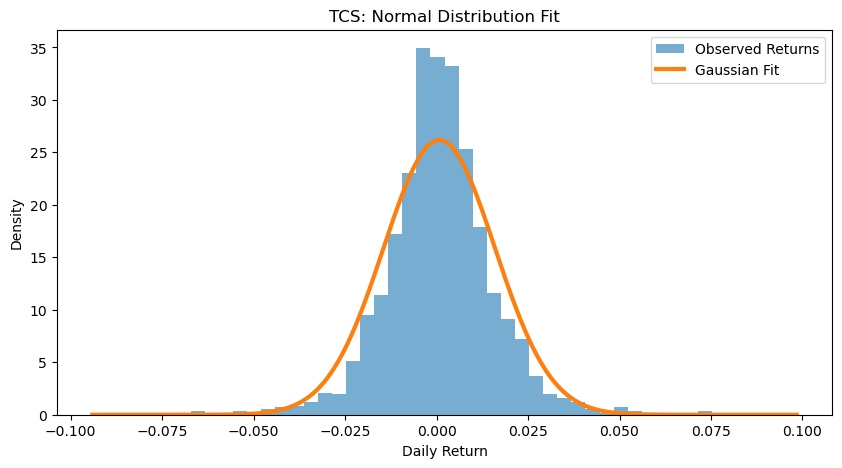

μ = 0.000735
σ = 0.015252
Log Likelihood = 4088.60

Processing Infosys ...


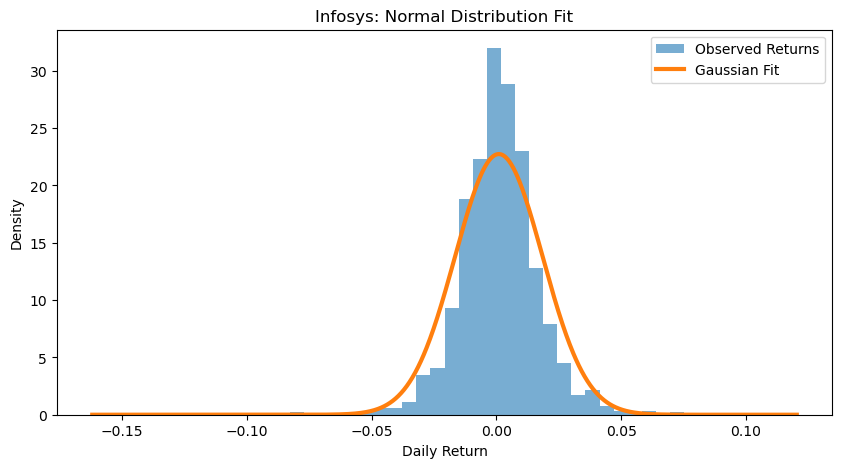

μ = 0.000972
σ = 0.017546
Log Likelihood = 3881.41

Processing Reliance ...


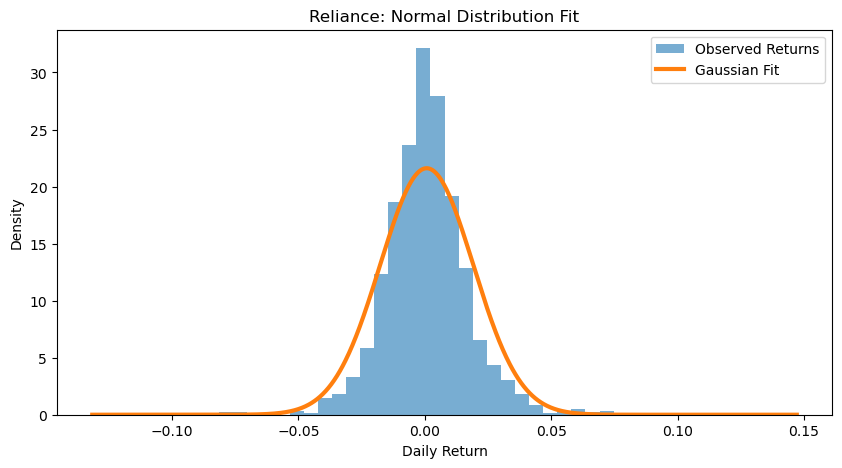

μ = 0.000767
σ = 0.018463
Log Likelihood = 3806.05

Processing HDFC ...


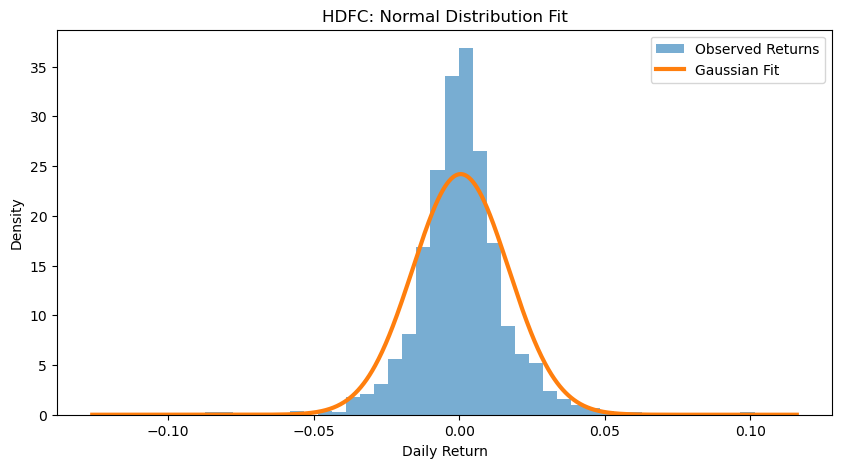

μ = 0.000510
σ = 0.016488
Log Likelihood = 3973.33

Processing ITC ...


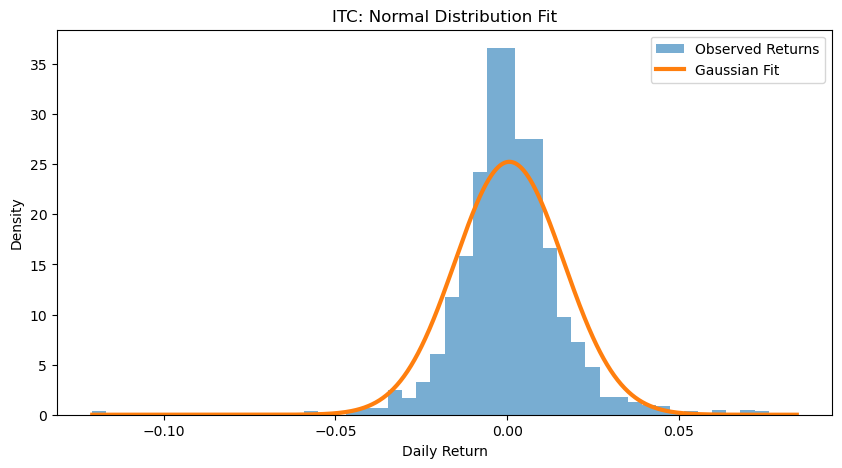

μ = 0.000645
σ = 0.015808
Log Likelihood = 4035.65


In [6]:
results = []

for stock in stocks:

    print(f"\nProcessing {stock} ...")

    # Load data
    df = pd.read_csv(f"Data_with_returns/{stock}_returns.csv")

    returns = df["Return"]

    # MLE Estimates
    mu_hat = returns.mean()

    sigma_hat = returns.std()

    # Log Likelihood
    log_likelihood = np.sum(
        norm.logpdf(
            returns,
            loc=mu_hat,
            scale=sigma_hat
        )
    ) # it shows Given μ and σ, observed returns how likely are

    # Save results
    results.append({
        "Stock": stock,
        "Mu_hat": mu_hat,
        "Sigma_hat": sigma_hat,
        "LogLikelihood": log_likelihood
    })

    # Generate Gaussian Fit
    x = np.linspace(
        returns.min(),
        returns.max(),
        1000
    )

    pdf = norm.pdf(
        x,
        loc=mu_hat,
        scale=sigma_hat
    )

    # Plot
    plt.figure(figsize=(10,5))

    plt.hist(
        returns,
        bins=50,
        density=True,
        alpha=0.6,
        label="Observed Returns"
    )

    plt.plot(
        x,
        pdf,
        linewidth=3,
        label="Gaussian Fit"
    )

    plt.xlabel("Daily Return")
    plt.ylabel("Density")

    plt.title(
        f"{stock}: Normal Distribution Fit"
    )

    plt.legend()

    plt.savefig(
        f"{stock}_gaussian_fit.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    print(f"μ = {mu_hat:.6f}")
    print(f"σ = {sigma_hat:.6f}")
    print(f"Log Likelihood = {log_likelihood:.2f}")

In [7]:
results_df = pd.DataFrame(results)

results_df

,Stock,Mu_hat,Sigma_hat,LogLikelihood
0,TCS,0.000735,0.015252,4088.604452
1,Infosys,0.000972,0.017546,3881.410230
2,Reliance,0.000767,0.018463,3806.054426
3,HDFC,0.000510,0.016488,3973.330757
4,ITC,0.000645,0.015808,4035.654091


Infosys exhibits the highest average daily return among the selected equities, while Reliance demonstrates the greatest volatility. TCS achieves a relatively favorable balance between return and risk, exhibiting moderate returns with the lowest observed volatility. These estimates provide initial parameter values for subsequent Bayesian inference.

In [9]:
results_df.to_csv(
    "likelihood_results.csv",
    index=False
)

